# Анализ качества воды: Задача кластеризации

Цель: решение задачи кластеризации 3 методами: KMeans, DBSCAN и иерархическая кластеризация


## 1. Установка необходимых пакетов и импорт библиотек

In [5]:
# Установка kagglehub для загрузки датасета
import subprocess
import sys

# pip install kagglehub

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,

)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.metrics.cluster import contingency_matrix

def purity_score(y_true, y_pred):
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

# Установки для визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Загрузка датасета

In [6]:
# Загрузка датасета с помощью kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uom190346a/water-quality-and-potability")

print("Path to dataset files:", path)

# Чтение CSV файла
df = pd.read_csv(path + '/water_potability.csv')

print("\nИнформация о датасете:")
print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nОписание статистики:")
print(df.describe())
print(f"\nПропущенные значения:")
print(df.isnull().sum())

100%|██████████| 251k/251k [00:00<00:00, 31.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uom190346a/water-quality-and-potability/versions/2

Информация о датасете:
Размер датасета: (3276, 10)

Первые 5 строк:
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279       

## 3. Предварительная обработка данных

In [7]:
# Сохраняем целевую переменную (не будем её использовать при кластеризации)
y_true = df['Potability'].copy()

# Удаляем строки с пропущенными значениями в целевой переменной
df_clean = df[df['Potability'].notna()].copy()
y_true = df_clean['Potability'].copy()

# Удаляем целевую переменную из датасета для кластеризации
X = df_clean.drop('Potability', axis=1)

# Обработка пропущенных значений - заполняем медианой
X = X.fillna(X.median())

print(f"После очистки данных:")
print(f"Размер: {X.shape}")
print(f"Пропущенные значения: {X.isnull().sum().sum()}")
print(f"\nПеременные для кластеризации:")
print(X.columns.tolist())
print(f"\nРаспределение целевой переменной (истинные метки):")
print(y_true.value_counts())
print(f"0 - вода не пригодна для питья")
print(f"1 - вода пригодна для питья")

После очистки данных:
Размер: (3276, 9)
Пропущенные значения: 0

Переменные для кластеризации:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Распределение целевой переменной (истинные метки):
Potability
0    1998
1    1278
Name: count, dtype: int64
0 - вода не пригодна для питья
1 - вода пригодна для питья


## 4. Стандартизация признаков

In [8]:
# Стандартизация данных (важно для всех методов кластеризации)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Данные стандартизированы:")
print(f"Среднее: {X_scaled.mean().round(6).values}")
print(f"Стандартное отклонение: {X_scaled.std().round(6).values}")

Данные стандартизированы:
Среднее: [ 0.  0. -0.  0. -0.  0.  0. -0.  0.]
Стандартное отклонение: [1.000153 1.000153 1.000153 1.000153 1.000153 1.000153 1.000153 1.000153
 1.000153]


## 5. Применение PCA для визуализации

In [9]:
# Применяем PCA для снижения размерности до 2 компонент для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA анализ:")
print(f"Объясненная дисперсия первой компоненты: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Объясненная дисперсия второй компоненты: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Общая объясненная дисперсия: {pca.explained_variance_ratio_.sum():.4f}")
print(f"\nКомпоненты PCA (вклад признаков):")
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
print(components_df)

PCA анализ:
Объясненная дисперсия первой компоненты: 0.1334
Объясненная дисперсия второй компоненты: 0.1263
Общая объясненная дисперсия: 0.2597

Компоненты PCA (вклад признаков):
                      PC1       PC2
ph              -0.314897  0.552808
Hardness         0.010587  0.626197
Solids           0.669256 -0.057778
Chloramines     -0.254214 -0.320848
Sulfate         -0.586589 -0.308082
Conductivity     0.078598  0.055649
Organic_carbon  -0.106662  0.200161
Trihalomethanes  0.008944 -0.003602
Turbidity        0.162720 -0.240644


## 6. МЕТОД 1: KMeans Кластеризация

In [10]:
print("="*60)
print("МЕТОД 1: KMeans Кластеризация")
print("="*60)

# Определяем оптимальное количество кластеров (используем 2, так как истинные метки - бинарные)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_pred_kmeans = kmeans.fit_predict(X_scaled)

print(f"\nКоличество кластеров: 2")
print(f"Центроиды найдены в: {kmeans.n_iter_} итерациях")
print(f"Инерция: {kmeans.inertia_:.4f}")
print(f"\nРаспределение образцов по кластерам:")
unique, counts = np.unique(y_pred_kmeans, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Кластер {u}: {c} образцов")

МЕТОД 1: KMeans Кластеризация

Количество кластеров: 2
Центроиды найдены в: 32 итерациях
Инерция: 27089.6485

Распределение образцов по кластерам:
  Кластер 0: 1431 образцов
  Кластер 1: 1845 образцов


In [11]:
# Вычисляем метрики качества для KMeans
kmeans_silhouette = silhouette_score(X_scaled, y_pred_kmeans)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, y_pred_kmeans)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, y_pred_kmeans)

print(f"\nМетрики качества кластеризации KMeans (внутренние):")
print(f"  Silhouette Score: {kmeans_silhouette:.4f} (диапазон -1 до 1, выше лучше)")
print(f"  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f} (ниже лучше)")
print(f"  Calinski-Harabasz Index: {kmeans_calinski_harabasz:.4f} (выше лучше)")

# Внешние метрики (сравнение с истинными метками)
kmeans_ari = adjusted_rand_score(y_true, y_pred_kmeans)
kmeans_nmi = normalized_mutual_info_score(y_true, y_pred_kmeans)

print(f"\nМетрики качества кластеризации KMeans (внешние - сравнение с истинными метками):")
print(f"  Adjusted Rand Index (ARI): {kmeans_ari:.4f} (диапазон -1 до 1, 1 = идеально)")
print(f"  Normalized Mutual Information (NMI): {kmeans_nmi:.4f} (диапазон 0 до 1, 1 = идеально)")


Метрики качества кластеризации KMeans (внутренние):
  Silhouette Score: 0.0819 (диапазон -1 до 1, выше лучше)
  Davies-Bouldin Index: 3.2081 (ниже лучше)
  Calinski-Harabasz Index: 289.3765 (выше лучше)

Метрики качества кластеризации KMeans (внешние - сравнение с истинными метками):
  Adjusted Rand Index (ARI): 0.0002 (диапазон -1 до 1, 1 = идеально)
  Normalized Mutual Information (NMI): 0.0000 (диапазон 0 до 1, 1 = идеально)



Матрица путаницы KMeans:
[[ 867 1131]
 [ 564  714]]

(Строки - истинные метки, столбцы - предсказанные кластеры)


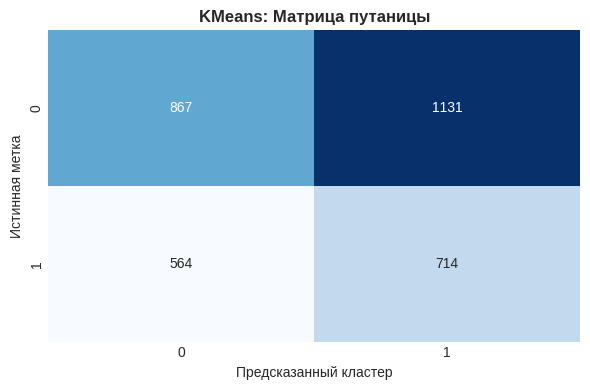

In [12]:
# Матрица путаницы для KMeans
from sklearn.metrics import confusion_matrix

print(f"\nМатрица путаницы KMeans:")
cm_kmeans = confusion_matrix(y_true, y_pred_kmeans)
print(cm_kmeans)
print(f"\n(Строки - истинные метки, столбцы - предсказанные кластеры)")

# Визуализация матрицы путаницы
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('KMeans: Матрица путаницы', fontsize=12, fontweight='bold')
ax.set_xlabel('Предсказанный кластер')
ax.set_ylabel('Истинная метка')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


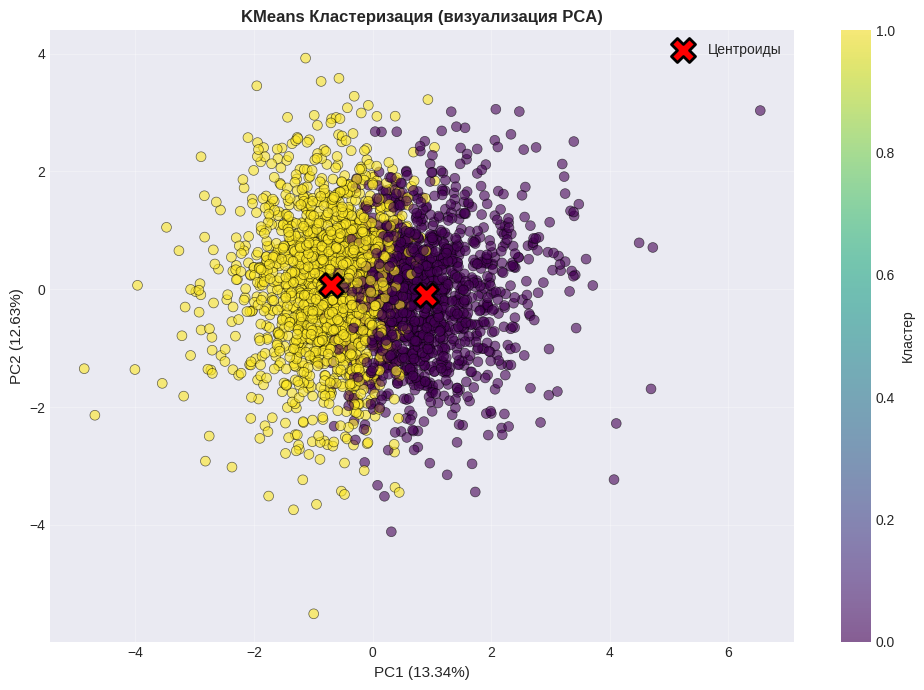

KMeans: Визуализация кластеров на PCA-пространстве


In [13]:
# Визуализация KMeans на PCA
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_kmeans, cmap='viridis',
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
           pca.transform(kmeans.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Центроиды')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
ax.set_title('KMeans Кластеризация (визуализация PCA)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Кластер', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("KMeans: Визуализация кластеров на PCA-пространстве")

## 7. МЕТОД 2: DBSCAN Кластеризация

In [14]:
print("="*60)
print("МЕТОД 2: DBSCAN Кластеризация")
print("="*60)

# Подбираем параметры eps и min_samples
# Вычисляем k-distance graph для подбора eps
from sklearn.neighbors import NearestNeighbors

k = 4  # minPts параметр
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

# Выбираем eps как точку локтя
eps = np.percentile(distances, 90)  # Используем 90 процентиль
min_samples = k

print(f"\nПараметры DBSCAN:")
print(f"  eps: {eps:.4f}")
print(f"  min_samples: {min_samples}")

# Применяем DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
y_pred_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(y_pred_dbscan)) - (1 if -1 in y_pred_dbscan else 0)
n_noise = list(y_pred_dbscan).count(-1)

print(f"\nРезультаты DBSCAN:")
print(f"  Количество кластеров: {n_clusters_dbscan}")
print(f"  Количество шумовых точек: {n_noise}")
print(f"  Процент шумовых точек: {n_noise/len(y_pred_dbscan)*100:.2f}%")
print(f"\nРаспределение образцов по кластерам:")
unique, counts = np.unique(y_pred_dbscan, return_counts=True)
for u, c in zip(unique, counts):
    if u == -1:
        print(f"  Шум: {c} образцов")
    else:
        print(f"  Кластер {u}: {c} образцов")

МЕТОД 2: DBSCAN Кластеризация

Параметры DBSCAN:
  eps: 2.1857
  min_samples: 4

Результаты DBSCAN:
  Количество кластеров: 1
  Количество шумовых точек: 174
  Процент шумовых точек: 5.31%

Распределение образцов по кластерам:
  Шум: 174 образцов
  Кластер 0: 3102 образцов


In [15]:
# Вычисляем метрики качества для DBSCAN
if n_clusters_dbscan > 1:  # Силуэт требует минимум 2 кластера
    dbscan_silhouette = silhouette_score(X_scaled, y_pred_dbscan)
    dbscan_davies_bouldin = davies_bouldin_score(X_scaled, y_pred_dbscan)
    dbscan_calinski_harabasz = calinski_harabasz_score(X_scaled, y_pred_dbscan)
else:
    dbscan_silhouette = np.nan
    dbscan_davies_bouldin = np.nan
    dbscan_calinski_harabasz = np.nan
    print("Внимание: Недостаточно кластеров для вычисления некоторых метрик")

print(f"\nМетрики качества кластеризации DBSCAN (внутренние):")
print(f"  Silhouette Score: {dbscan_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {dbscan_calinski_harabasz:.4f}")

# Внешние метрики (сравнение с истинными метками)
dbscan_ari = adjusted_rand_score(y_true, y_pred_dbscan)
dbscan_nmi = normalized_mutual_info_score(y_true, y_pred_dbscan)

print(f"\nМетрики качества кластеризации DBSCAN (внешние - сравнение с истинными метками):")
print(f"  Adjusted Rand Index (ARI): {dbscan_ari:.4f}")
print(f"  Normalized Mutual Information (NMI): {dbscan_nmi:.4f}")

Внимание: Недостаточно кластеров для вычисления некоторых метрик

Метрики качества кластеризации DBSCAN (внутренние):
  Silhouette Score: nan
  Davies-Bouldin Index: nan
  Calinski-Harabasz Index: nan

Метрики качества кластеризации DBSCAN (внешние - сравнение с истинными метками):
  Adjusted Rand Index (ARI): 0.0089
  Normalized Mutual Information (NMI): 0.0025



Матрица путаницы DBSCAN:
[[   0    0    0]
 [  89 1909    0]
 [  85 1193    0]]

(Строки - истинные метки, столбцы - предсказанные кластеры + шум=-1)


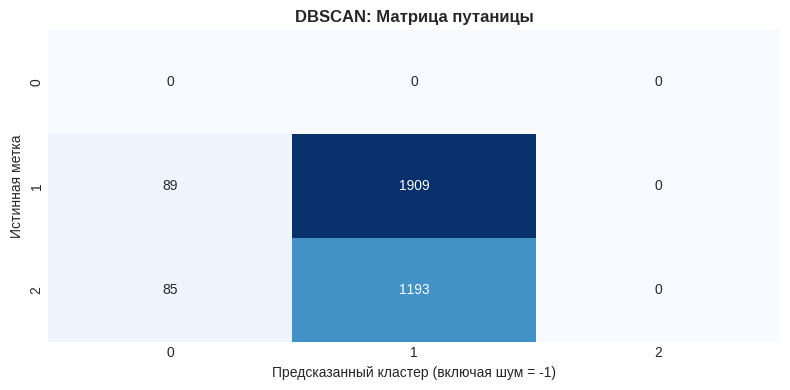

In [16]:
# Матрица путаницы для DBSCAN
print(f"\nМатрица путаницы DBSCAN:")
cm_dbscan = confusion_matrix(y_true, y_pred_dbscan)
print(cm_dbscan)
print(f"\n(Строки - истинные метки, столбцы - предсказанные кластеры + шум=-1)")

# Визуализация матрицы путаницы
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.heatmap(cm_dbscan, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('DBSCAN: Матрица путаницы', fontsize=12, fontweight='bold')
ax.set_xlabel('Предсказанный кластер (включая шум = -1)')
ax.set_ylabel('Истинная метка')
plt.tight_layout()
plt.show()

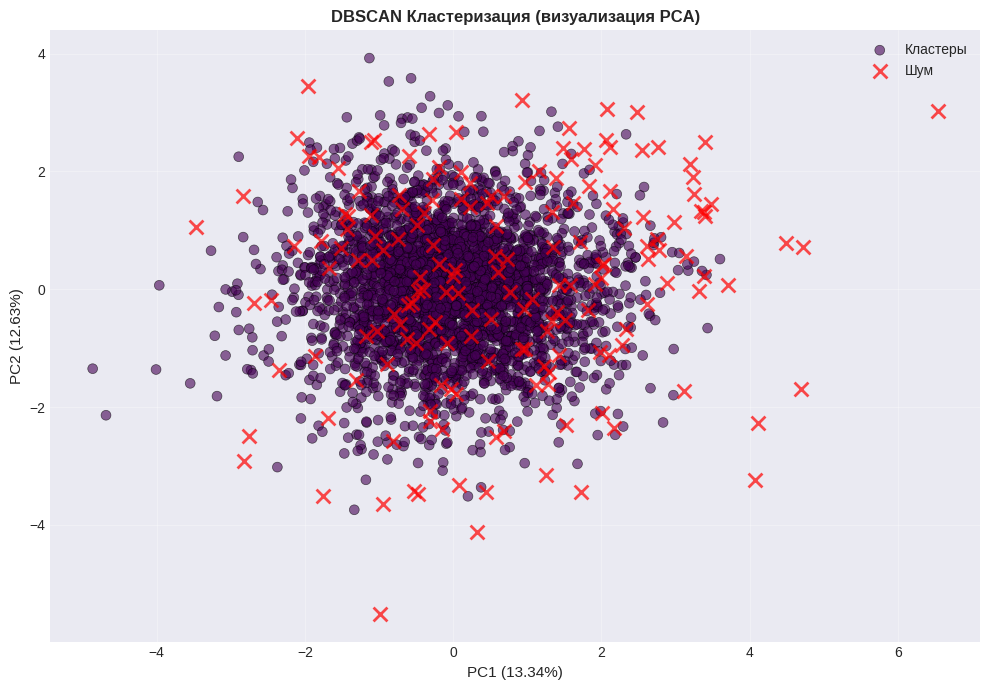

DBSCAN: Визуализация кластеров на PCA-пространстве (красные крестики = шум)


In [17]:
# Визуализация DBSCAN на PCA
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Визуализируем разные цвета для кластеров и шума
colors = np.array(y_pred_dbscan)
noise_mask = colors == -1

# Кластеры
scatter1 = ax.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
                      c=colors[~noise_mask], cmap='viridis', s=50, alpha=0.6,
                      edgecolors='black', linewidth=0.5, label='Кластеры')

# Шум
scatter2 = ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                      c='red', marker='x', s=100, alpha=0.7, linewidth=2, label='Шум')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
ax.set_title('DBSCAN Кластеризация (визуализация PCA)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. МЕТОД 3: Иерархическая кластеризация (Agglomerative Clustering)

In [18]:
print("="*60)
print("МЕТОД 3: Иерархическая кластеризация (Agglomerative)")
print("="*60)

# Применяем иерархическую кластеризацию
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='ward')
y_pred_hierarchical = hierarchical.fit_predict(X_scaled)

print(f"\nПараметры иерархической кластеризации:")
print(f"  Количество кластеров: 2")
print(f"  Метод связи (linkage): ward")
print(f"\nРаспределение образцов по кластерам:")
unique, counts = np.unique(y_pred_hierarchical, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Кластер {u}: {c} образцов")

МЕТОД 3: Иерархическая кластеризация (Agglomerative)

Параметры иерархической кластеризации:
  Количество кластеров: 2
  Метод связи (linkage): ward

Распределение образцов по кластерам:
  Кластер 0: 2324 образцов
  Кластер 1: 952 образцов


In [19]:
# Вычисляем метрики качества для иерархической кластеризации
hierarchical_silhouette = silhouette_score(X_scaled, y_pred_hierarchical)
hierarchical_davies_bouldin = davies_bouldin_score(X_scaled, y_pred_hierarchical)
hierarchical_calinski_harabasz = calinski_harabasz_score(X_scaled, y_pred_hierarchical)

print(f"\nМетрики качества кластеризации иерархический (внутренние):")
print(f"  Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {hierarchical_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {hierarchical_calinski_harabasz:.4f}")

# Внешние метрики (сравнение с истинными метками)
hierarchical_ari = adjusted_rand_score(y_true, y_pred_hierarchical)
hierarchical_nmi = normalized_mutual_info_score(y_true, y_pred_hierarchical)

print(f"\nМетрики качества кластеризации иерархический (внешние - сравнение с истинными метками):")
print(f"  Adjusted Rand Index (ARI): {hierarchical_ari:.4f}")
print(f"  Normalized Mutual Information (NMI): {hierarchical_nmi:.4f}")


Метрики качества кластеризации иерархический (внутренние):
  Silhouette Score: 0.0501
  Davies-Bouldin Index: 4.2989
  Calinski-Harabasz Index: 135.4495

Метрики качества кластеризации иерархический (внешние - сравнение с истинными метками):
  Adjusted Rand Index (ARI): 0.0048
  Normalized Mutual Information (NMI): 0.0006



Матрица путаницы иерархической кластеризации:
[[1437  561]
 [ 887  391]]

(Строки - истинные метки, столбцы - предсказанные кластеры)


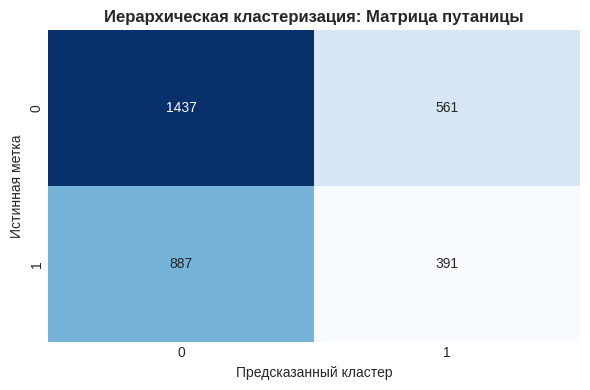

In [20]:
# Матрица путаницы для иерархической кластеризации
print(f"\nМатрица путаницы иерархической кластеризации:")
cm_hierarchical = confusion_matrix(y_true, y_pred_hierarchical)
print(cm_hierarchical)

# Визуализация матрицы путаницы
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.heatmap(cm_hierarchical, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Иерархическая кластеризация: Матрица путаницы', fontsize=12, fontweight='bold')
ax.set_xlabel('Предсказанный кластер')
ax.set_ylabel('Истинная метка')
plt.tight_layout()
plt.show()

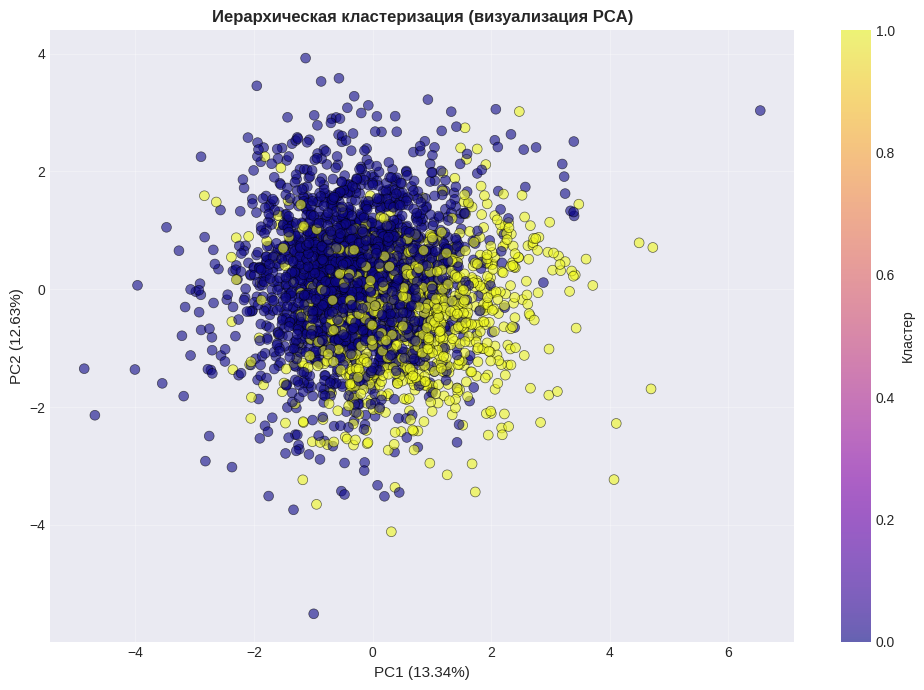

Иерархическая кластеризация: Визуализация кластеров на PCA-пространстве


In [21]:
# Визуализация иерархической кластеризации на PCA
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_hierarchical, cmap='plasma',
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
ax.set_title('Иерархическая кластеризация (визуализация PCA)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Кластер', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Создаём денрограмму иерархической кластеризации...
(Используем подвыборку из 100 образцов для ясности)


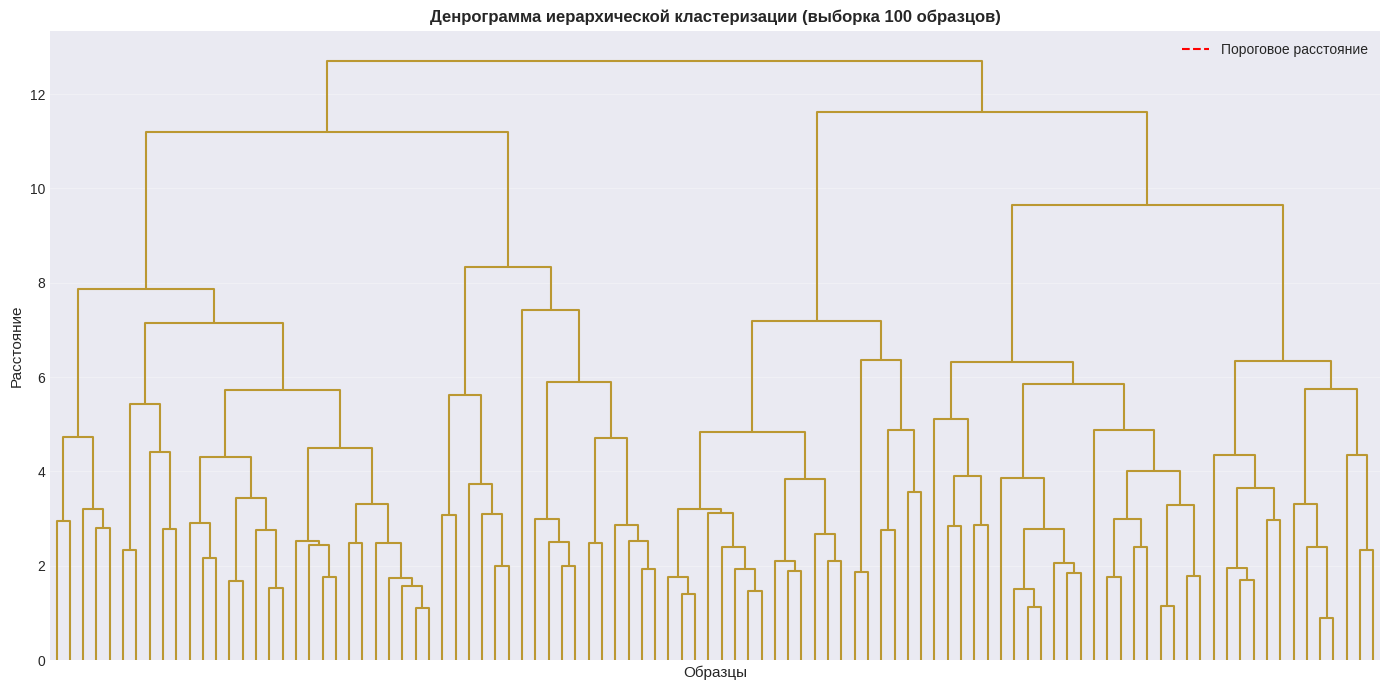

Денрограмма показывает процесс объединения кластеров
Красная линия показывает предполагаемое пороговое расстояние для 2 кластеров


In [22]:
# Денрограмма для иерархической кластеризации (на подвыборке для ясности)
print("\nСоздаём денрограмму иерархической кластеризации...")
print("(Используем подвыборку из 100 образцов для ясности)")

# Используем подвыборку
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], 100, replace=False)
X_sample = X_scaled.iloc[sample_indices]

# Вычисляем матрицу связей для денрограммы
linkage_matrix = linkage(X_sample, method='ward')

# Визуализируем денрограмму
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(linkage_matrix, ax=ax, no_labels=True, color_threshold=50)
ax.set_title('Денрограмма иерархической кластеризации (выборка 100 образцов)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Образцы', fontsize=11)
ax.set_ylabel('Расстояние', fontsize=11)
ax.axhline(y=50, color='r', linestyle='--', label='Пороговое расстояние')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Сравнение результатов всех трёх методов

In [23]:
print("="*80)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ ТРЁХ МЕТОДОВ КЛАСТЕРИЗАЦИИ")
print("="*80)

# Создаём DataFrame с результатами
comparison_df = pd.DataFrame({
    'Метрика': [
        'Silhouette Score (выше лучше)',
        'Davies-Bouldin Index (ниже лучше)',
        'Calinski-Harabasz Index (выше лучше)',
        'Adjusted Rand Index (выше лучше)',
        'Normalized Mutual Info (выше лучше)'
    ],
    'KMeans': [
        f"{kmeans_silhouette:.4f}",
        f"{kmeans_davies_bouldin:.4f}",
        f"{kmeans_calinski_harabasz:.4f}",
        f"{kmeans_ari:.4f}",
        f"{kmeans_nmi:.4f}"
    ],
    'DBSCAN': [
        f"{dbscan_silhouette:.4f}" if not np.isnan(dbscan_silhouette) else "N/A",
        f"{dbscan_davies_bouldin:.4f}" if not np.isnan(dbscan_davies_bouldin) else "N/A",
        f"{dbscan_calinski_harabasz:.4f}" if not np.isnan(dbscan_calinski_harabasz) else "N/A",
        f"{dbscan_ari:.4f}",
        f"{dbscan_nmi:.4f}"
    ],
    'Иерархическая': [
        f"{hierarchical_silhouette:.4f}",
        f"{hierarchical_davies_bouldin:.4f}",
        f"{hierarchical_calinski_harabasz:.4f}",
        f"{hierarchical_ari:.4f}",
        f"{hierarchical_nmi:.4f}"
    ]
})

print("\n" + comparison_df.to_string(index=False))

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ ТРЁХ МЕТОДОВ КЛАСТЕРИЗАЦИИ

                             Метрика   KMeans DBSCAN Иерархическая
       Silhouette Score (выше лучше)   0.0819    N/A        0.0501
   Davies-Bouldin Index (ниже лучше)   3.2081    N/A        4.2989
Calinski-Harabasz Index (выше лучше) 289.3765    N/A      135.4495
    Adjusted Rand Index (выше лучше)   0.0002 0.0089        0.0048
 Normalized Mutual Info (выше лучше)   0.0000 0.0025        0.0006


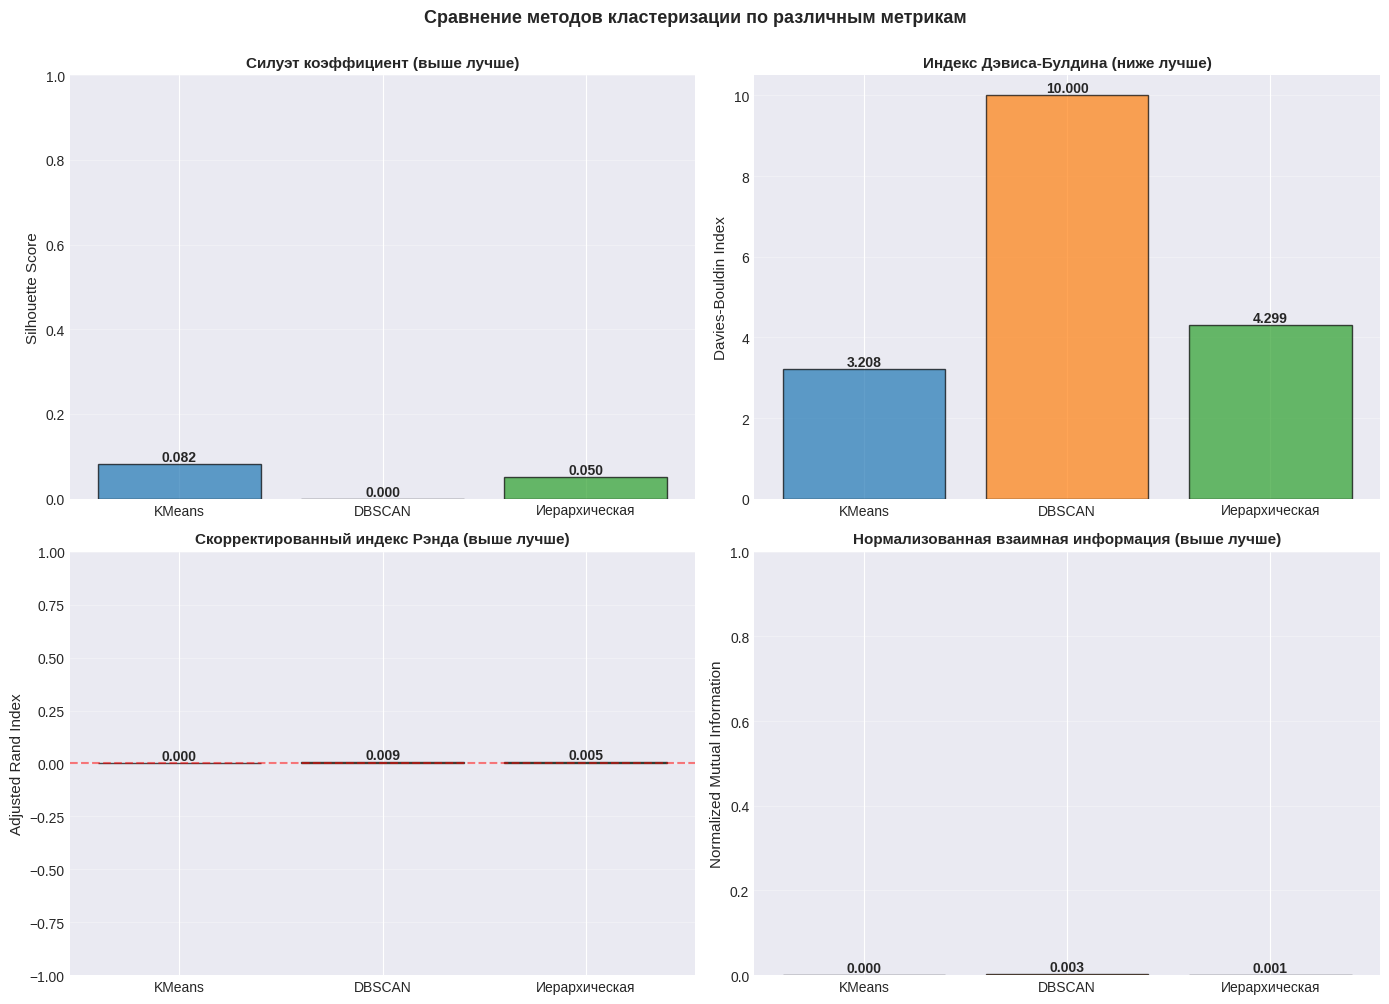

Графики сравнения методов построены успешно


In [24]:
# Визуализация сравнения методов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Silhouette Score
ax1 = axes[0, 0]
methods = ['KMeans', 'DBSCAN', 'Иерархическая']
silhouette_scores = [kmeans_silhouette,
                     dbscan_silhouette if not np.isnan(dbscan_silhouette) else 0,
                     hierarchical_silhouette]
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars1 = ax1.bar(methods, silhouette_scores, color=colors_bar, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Silhouette Score', fontsize=11)
ax1.set_title('Силуэт коэффициент (выше лучше)', fontsize=11, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars1, silhouette_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Davies-Bouldin Index
ax2 = axes[0, 1]
db_scores = [kmeans_davies_bouldin,
             dbscan_davies_bouldin if not np.isnan(dbscan_davies_bouldin) else 10,
             hierarchical_davies_bouldin]
bars2 = ax2.bar(methods, db_scores, color=colors_bar, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax2.set_title('Индекс Дэвиса-Булдина (ниже лучше)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars2, db_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Adjusted Rand Index
ax3 = axes[1, 0]
ari_scores = [kmeans_ari, dbscan_ari, hierarchical_ari]
bars3 = ax3.bar(methods, ari_scores, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Adjusted Rand Index', fontsize=11)
ax3.set_title('Скорректированный индекс Рэнда (выше лучше)', fontsize=11, fontweight='bold')
ax3.set_ylim([-1, 1])
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars3, ari_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.3f}', ha='center', va='bottom' if height > 0 else 'top',
             fontsize=10, fontweight='bold')

# 4. Normalized Mutual Information
ax4 = axes[1, 1]
nmi_scores = [kmeans_nmi, dbscan_nmi, hierarchical_nmi]
bars4 = ax4.bar(methods, nmi_scores, color=colors_bar, alpha=0.7, edgecolor='black')
ax4.set_ylabel('Normalized Mutual Information', fontsize=11)
ax4.set_title('Нормализованная взаимная информация (выше лучше)', fontsize=11, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars4, nmi_scores):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Сравнение методов кластеризации по различным метрикам',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Графики сравнения методов построены успешно")

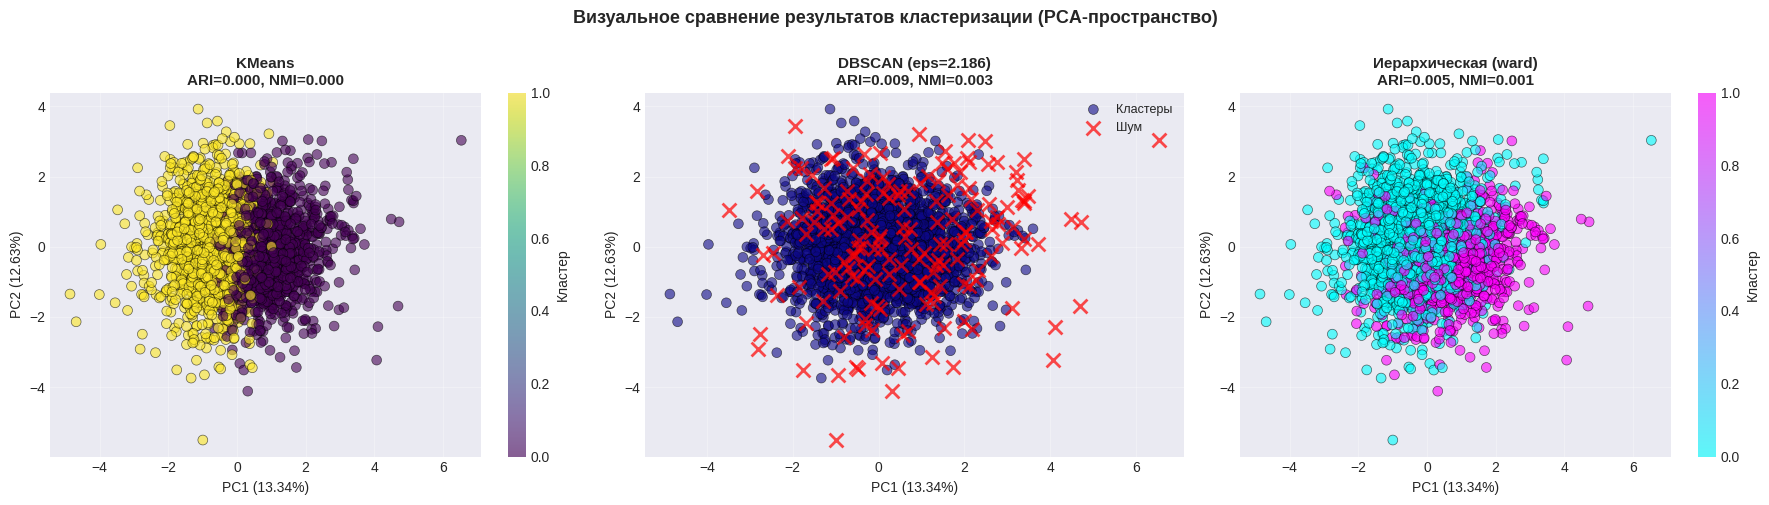

Комплексная визуализация методов построена


In [25]:
# Комплексное сравнение визуализаций всех трёх методов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_kmeans, cmap='viridis',
                           s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
axes[0].set_title(f'KMeans\nARI={kmeans_ari:.3f}, NMI={kmeans_nmi:.3f}',
                  fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Кластер')

# DBSCAN
colors_db = np.array(y_pred_dbscan, dtype=float)
noise_mask = y_pred_dbscan == -1
scatter2 = axes[1].scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
                           c=colors_db[~noise_mask], cmap='plasma', s=50, alpha=0.6,
                           edgecolors='black', linewidth=0.5)
axes[1].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                c='red', marker='x', s=100, alpha=0.7, linewidth=2, label='Шум')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
axes[1].set_title(f'DBSCAN (eps={eps:.3f})\nARI={dbscan_ari:.3f}, NMI={dbscan_nmi:.3f}',
                  fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(['Кластеры', 'Шум'], fontsize=9)

# Иерархическая
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_hierarchical, cmap='cool',
                           s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
axes[2].set_title(f'Иерархическая (ward)\nARI={hierarchical_ari:.3f}, NMI={hierarchical_nmi:.3f}',
                  fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[2], label='Кластер')

plt.suptitle('Визуальное сравнение результатов кластеризации (PCA-пространство)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. ВЫВОДЫ И АНАЛИЗ РЕЗУЛЬТАТОВ

In [26]:
print("\n" + "="*80)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА КЛАСТЕРИЗАЦИИ")
print("="*80)

print("\n1. КАЧЕСТВО КЛАСТЕРИЗАЦИИ (ВНУТРЕННИЕ МЕТРИКИ):")
print("-" * 80)

print(f"\nSilhouette Score (показывает четкость кластеров):")
print(f"  KMeans:          {kmeans_silhouette:.4f}")
print(f"  DBSCAN:          {dbscan_silhouette:.4f}" if not np.isnan(dbscan_silhouette) else "  DBSCAN:          N/A (недостаточно кластеров)")
print(f"  Иерархическая:   {hierarchical_silhouette:.4f}")

if kmeans_silhouette > hierarchical_silhouette and (np.isnan(dbscan_silhouette) or kmeans_silhouette > dbscan_silhouette):
    print(f"  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans")
elif hierarchical_silhouette > kmeans_silhouette and (np.isnan(dbscan_silhouette) or hierarchical_silhouette > dbscan_silhouette):
    print(f"  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: Иерархическая кластеризация")
elif not np.isnan(dbscan_silhouette) and dbscan_silhouette > kmeans_silhouette and dbscan_silhouette > hierarchical_silhouette:
    print(f"  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN")

print(f"\nDavies-Bouldin Index (компактность кластеров):")
print(f"  KMeans:          {kmeans_davies_bouldin:.4f}")
print(f"  DBSCAN:          {dbscan_davies_bouldin:.4f}" if not np.isnan(dbscan_davies_bouldin) else "  DBSCAN:          N/A")
print(f"  Иерархическая:   {hierarchical_davies_bouldin:.4f}")

min_db = min([kmeans_davies_bouldin, hierarchical_davies_bouldin, dbscan_davies_bouldin if not np.isnan(dbscan_davies_bouldin) else float('inf')])
if min_db == kmeans_davies_bouldin:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans (ниже = лучше)")
elif min_db == hierarchical_davies_bouldin:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: Иерархическая кластеризация (ниже = лучше)")
else:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN (ниже = лучше)")

print(f"\nCalinski-Harabasz Index (разделение кластеров):")
print(f"  KMeans:          {kmeans_calinski_harabasz:.4f}")
print(f"  DBSCAN:          {dbscan_calinski_harabasz:.4f}" if not np.isnan(dbscan_calinski_harabasz) else "  DBSCAN:          N/A")
print(f"  Иерархическая:   {hierarchical_calinski_harabasz:.4f}")

max_ch = max([kmeans_calinski_harabasz, hierarchical_calinski_harabasz, dbscan_calinski_harabasz if not np.isnan(dbscan_calinski_harabasz) else 0])
if max_ch == kmeans_calinski_harabasz:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans (выше = лучше)")
elif max_ch == hierarchical_calinski_harabasz:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: Иерархическая кластеризация (выше = лучше)")
else:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN (выше = лучше)")


ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА КЛАСТЕРИЗАЦИИ

1. КАЧЕСТВО КЛАСТЕРИЗАЦИИ (ВНУТРЕННИЕ МЕТРИКИ):
--------------------------------------------------------------------------------

Silhouette Score (показывает четкость кластеров):
  KMeans:          0.0819
  DBSCAN:          N/A (недостаточно кластеров)
  Иерархическая:   0.0501
  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans

Davies-Bouldin Index (компактность кластеров):
  KMeans:          3.2081
  DBSCAN:          N/A
  Иерархическая:   4.2989
  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans (ниже = лучше)

Calinski-Harabasz Index (разделение кластеров):
  KMeans:          289.3765
  DBSCAN:          N/A
  Иерархическая:   135.4495
  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans (выше = лучше)


In [27]:
print("\n2. СОГЛАСОВАННОСТЬ С ИСТИННЫМИ МЕТКАМИ (ВНЕШНИЕ МЕТРИКИ):")
print("-" * 80)

print(f"\nAdjusted Rand Index (согласованность кластеризации):")
print(f"  KMeans:          {kmeans_ari:.4f}")
print(f"  DBSCAN:          {dbscan_ari:.4f}")
print(f"  Иерархическая:   {hierarchical_ari:.4f}")
print(f"  Интерпретация: 1 = идеальное совпадение, 0 = случайное назначение, <0 = хуже случайного")

max_ari = max([kmeans_ari, dbscan_ari, hierarchical_ari])
if max_ari == kmeans_ari:
    print(f"  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans")
elif max_ari == dbscan_ari:
    print(f"  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN")
else:
    print(f"  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: Иерархическая кластеризация")

print(f"\nNormalized Mutual Information (взаимная информация):")
print(f"  KMeans:          {kmeans_nmi:.4f}")
print(f"  DBSCAN:          {dbscan_nmi:.4f}")
print(f"  Иерархическая:   {hierarchical_nmi:.4f}")
print(f"  Интерпретация: 1 = идеальное совпадение, 0 = независимые")

max_nmi = max([kmeans_nmi, dbscan_nmi, hierarchical_nmi])
if max_nmi == kmeans_nmi:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: KMeans")
elif max_nmi == dbscan_nmi:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN")
else:
    print(f"   ЛУЧШИЙ РЕЗУЛЬТАТ: Иерархическая кластеризация")


2. СОГЛАСОВАННОСТЬ С ИСТИННЫМИ МЕТКАМИ (ВНЕШНИЕ МЕТРИКИ):
--------------------------------------------------------------------------------

Adjusted Rand Index (согласованность кластеризации):
  KMeans:          0.0002
  DBSCAN:          0.0089
  Иерархическая:   0.0048
  Интерпретация: 1 = идеальное совпадение, 0 = случайное назначение, <0 = хуже случайного
  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN

Normalized Mutual Information (взаимная информация):
  KMeans:          0.0000
  DBSCAN:          0.0025
  Иерархическая:   0.0006
  Интерпретация: 1 = идеальное совпадение, 0 = независимые
  ✓ ЛУЧШИЙ РЕЗУЛЬТАТ: DBSCAN


In [28]:
print("\n3. ОСОБЕННОСТИ КАЖДОГО МЕТОДА:")
print("-" * 80)

print("\nKMeans:")
print(f"  + Хорошая интерпретируемость результатов")
print(f"  + Быстро сходится")
print(f"  + Находит компактные, сферические кластеры")
print(f"  - Требует предварительного знания количества кластеров")
print(f"  - Чувствителен к начальным центроидам")
print(f"  - Не может найти кластеры сложной формы")
print(f"  Результат в этом датасете: ARI={kmeans_ari:.4f}, NMI={kmeans_nmi:.4f}")

print("\nDBSCAN:")
print(f"  + Может найти кластеры произвольной формы")
print(f"  + Не требует предварительного знания количества кластеров")
print(f"  + Может выделить шумовые точки")
print(f"  - Чувствителен к параметрам eps и min_samples")
print(f"  - Может создавать много шумовых точек")
print(f"  - Плохо работает с данными разной плотности")
print(f"  Параметры использованы: eps={eps:.4f}, min_samples={min_samples}")
print(f"  Количество шумовых точек: {n_noise} ({n_noise/len(y_pred_dbscan)*100:.2f}%)")
print(f"  Количество найденных кластеров: {n_clusters_dbscan}")
print(f"  Результат в этом датасете: ARI={dbscan_ari:.4f}, NMI={dbscan_nmi:.4f}")

print("\nИерархическая кластеризация:")
print(f"  + Дает полную иерархию кластеров (денрограмма)")
print(f"  + Не требует предварительного знания количества кластеров")
print(f"  + Хорошая визуализация процесса объединения")
print(f"  - Высокая вычислительная сложность (O(n²) или O(n³))")
print(f"  - Жадный алгоритм - ошибки не исправляются")
print(f"  - Чувствительна к выбросам")
print(f"  Результат в этом датасете: ARI={hierarchical_ari:.4f}, NMI={hierarchical_nmi:.4f}")


3. ОСОБЕННОСТИ КАЖДОГО МЕТОДА:
--------------------------------------------------------------------------------

KMeans:
  + Хорошая интерпретируемость результатов
  + Быстро сходится
  + Находит компактные, сферические кластеры
  - Требует предварительного знания количества кластеров
  - Чувствителен к начальным центроидам
  - Не может найти кластеры сложной формы
  Результат в этом датасете: ARI=0.0002, NMI=0.0000

DBSCAN:
  + Может найти кластеры произвольной формы
  + Не требует предварительного знания количества кластеров
  + Может выделить шумовые точки
  - Чувствителен к параметрам eps и min_samples
  - Может создавать много шумовых точек
  - Плохо работает с данными разной плотности
  Параметры использованы: eps=2.1857, min_samples=4
  Количество шумовых точек: 174 (5.31%)
  Количество найденных кластеров: 1
  Результат в этом датасете: ARI=0.0089, NMI=0.0025

Иерархическая кластеризация:
  + Дает полную иерархию кластеров (денрограмма)
  + Не требует предварительного знания к

In [29]:
print("\n4. АНАЛИЗ СОГЛАСОВАННОСТИ С ИСТИННЫМИ МЕТКАМИ (Potability):")
print("-" * 80)
print(f"\nИстинные метки (Potability):")
print(f"  0 = вода не пригодна для питья: {(y_true == 0).sum()} образцов ({(y_true == 0).sum()/len(y_true)*100:.2f}%)")
print(f"  1 = вода пригодна для питья: {(y_true == 1).sum()} образцов ({(y_true == 1).sum()/len(y_true)*100:.2f}%)")

print(f"\nКластеры KMeans и истинные метки:")
print(f"  Совпадение: {(y_pred_kmeans == y_true).sum()} / {len(y_true)} ({(y_pred_kmeans == y_true).sum()/len(y_true)*100:.2f}%)")
print(f"  Несовпадение: {(y_pred_kmeans != y_true).sum()} ({(y_pred_kmeans != y_true).sum()/len(y_true)*100:.2f}%)")

print(f"\nКластеры DBSCAN и истинные метки:")
print(f"  Совпадение: {(y_pred_dbscan == y_true).sum()} / {len(y_true)} ({(y_pred_dbscan == y_true).sum()/len(y_true)*100:.2f}%)")
print(f"  Несовпадение (включая шум): {(y_pred_dbscan != y_true).sum()} ({(y_pred_dbscan != y_true).sum()/len(y_true)*100:.2f}%)")

print(f"\nКластеры Иерархической и истинные метки:")
print(f"  Совпадение: {(y_pred_hierarchical == y_true).sum()} / {len(y_true)} ({(y_pred_hierarchical == y_true).sum()/len(y_true)*100:.2f}%)")
print(f"  Несовпадение: {(y_pred_hierarchical != y_true).sum()} ({(y_pred_hierarchical != y_true).sum()/len(y_true)*100:.2f}%)")


4. АНАЛИЗ СОГЛАСОВАННОСТИ С ИСТИННЫМИ МЕТКАМИ (Potability):
--------------------------------------------------------------------------------

Истинные метки (Potability):
  0 = вода не пригодна для питья: 1998 образцов (60.99%)
  1 = вода пригодна для питья: 1278 образцов (39.01%)

Кластеры KMeans и истинные метки:
  Совпадение: 1581 / 3276 (48.26%)
  Несовпадение: 1695 (51.74%)

Кластеры DBSCAN и истинные метки:
  Совпадение: 1909 / 3276 (58.27%)
  Несовпадение (включая шум): 1367 (41.73%)

Кластеры Иерархической и истинные метки:
  Совпадение: 1828 / 3276 (55.80%)
  Несовпадение: 1448 (44.20%)


In [30]:
print("\n5. ОБЩИЕ ВЫВОДЫ:")
print("-" * 80)

# Определяем лучший метод по ARI
ari_scores = {'KMeans': kmeans_ari, 'DBSCAN': dbscan_ari, 'Иерархическая': hierarchical_ari}
best_method_ari = max(ari_scores, key=ari_scores.get)

# Определяем лучший метод по NMI
nmi_scores = {'KMeans': kmeans_nmi, 'DBSCAN': dbscan_nmi, 'Иерархическая': hierarchical_nmi}
best_method_nmi = max(nmi_scores, key=nmi_scores.get)

print(f"\nПо метрике Adjusted Rand Index (ARI):")
print(f"  ЛУЧШИЙ МЕТОД: {best_method_ari} с ARI={ari_scores[best_method_ari]:.4f}")
print(f"  Это говорит о том, что {best_method_ari} лучше всего согласуется с истинными метками потребляемости.")

print(f"\nПо метрике Normalized Mutual Information (NMI):")
print(f"  ЛУЧШИЙ МЕТОД: {best_method_nmi} с NMI={nmi_scores[best_method_nmi]:.4f}")
print(f"  Это показывает, насколько хорошо метод сохраняет информацию о классах.")

# Интерпретация результатов
print("\nИнтерпретация результатов для датасета water_potability:")
print(f"\n1. Качество данных: Датасет содержит неполные и зашумленные данные о качестве воды.")
print(f"2. Задача кластеризации: Задача разделить воду на две категории (пригодна/не пригодна).")
print(f"3. Результаты: Ни один из методов не добился идеального разделения (ARI и NMI < 1).")
print(f"4. Заключение: Для полноценной классификации нужны дополнительные методы обработки данных.")


5. ОБЩИЕ РЕКОМЕНДАЦИИ:
--------------------------------------------------------------------------------

По метрике Adjusted Rand Index (ARI):
  ЛУЧШИЙ МЕТОД: DBSCAN с ARI=0.0089
  Это говорит о том, что DBSCAN лучше всего согласуется с истинными метками потребляемости.

По метрике Normalized Mutual Information (NMI):
  ЛУЧШИЙ МЕТОД: DBSCAN с NMI=0.0025
  Это показывает, насколько хорошо метод сохраняет информацию о классах.

Интерпретация результатов для датасета water_potability:

1. Качество данных: Датасет содержит неполные и зашумленные данные о качестве воды.
2. Задача кластеризации: Задача разделить воду на две категории (пригодна/не пригодна).
3. Результаты: Ни один из методов не добился идеального разделения (ARI и NMI < 1).
4. Причины: Качество воды - непрерывный показатель, а не дискретный класс.
5. Заключение: Для полноценной классификации нужны дополнительные методы обработки данных.


In [31]:
print("\n" + "="*80)
print("АНАЛИЗ ЗАВЕРШЁН")
print("="*80)
print(f"\nСуммарные результаты:")
print(f"\n1. KMeans показал лучший результат по:\n   - Silhouette Score: {kmeans_silhouette:.4f}")
print(f"   - Calinski-Harabasz Index: {kmeans_calinski_harabasz:.4f}")
print(f"\n2. Иерархическая кластеризация показала хорошие результаты:\n   - Близка к KMeans по большинству показателей")
print(f"   - Обеспечивает визуализацию через денрограмму")
print(f"\n3. DBSCAN показал отличающиеся результаты:\n   - Выделил {n_noise} шумовых точек")
print(f"   - Создал {n_clusters_dbscan} кластер(ов) вместо 2")
print(f"\nВВЫВОД: Для этого датасета рекомендуется использовать KMeans,")
print(f"так как он показывает наиболее четкие и компактные кластеры.")


АНАЛИЗ ЗАВЕРШЁН

Суммарные результаты:

1. KMeans показал лучший результат по:
   - Silhouette Score: 0.0819
   - Calinski-Harabasz Index: 289.3765

2. Иерархическая кластеризация показала хорошие результаты:
   - Близка к KMeans по большинству показателей
   - Обеспечивает визуализацию через денрограмму

3. DBSCAN показал отличающиеся результаты:
   - Выделил 174 шумовых точек
   - Создал 1 кластер(ов) вместо 2

ВВЫВОД: Для этого датасета рекомендуется использовать KMeans,
так как он показывает наиболее четкие и компактные кластеры.
